# Order Parameters and Phenotypes

In this notebook, we analyze both the order parameters and the fraction of elongated cells.

We will use the information available in the folder `dat_order_parameters` which has the information of the global order parameters during the simulations at each time step and for each seed.

We define different order parameters in order to visualize how is the structure:

- Nematic Order ($Q$): The well-known nematic order calculated using the number of elongated cells as follows:

$$ Q = \frac{1}{N_e} \sqrt{\left(\sum_{i=1}^{N_e} \sin (2\varphi_i)\right)^2+\left(\sum_{i=1}^{N_e} \cos (2\varphi_i)\right)^2}$$

- Polar Order ($P$): The well-known polar order calculated using the number of elongated cells as follows:

$$ P = \frac{1}{N_e} \sqrt{\left(\sum_{i=1}^{N_e} \sin (\varphi_i)\right)^2+\left(\sum_{i=1}^{N_e} \cos (\varphi_i)\right)^2}$$

- Nematic Order 2 ($\hat{Q}$): The same nematic parameter as before but dividing by all the cells (including the rounds):

$$ \hat{Q} = \frac{1}{N} \sqrt{\left(\sum_{i=1}^{N_e} \sin (2\varphi_i)\right)^2+\left(\sum_{i=1}^{N_e} \cos (2\varphi_i)\right)^2}$$

- Polar Order 2 ($\hat{P}$): The same polar parameter as before but dividing by all the cells (including the rounds):

$$ \hat{P} = \frac{1}{N} \sqrt{\left(\sum_{i=1}^{N_e} \sin (\varphi_i)\right)^2+\left(\sum_{i=1}^{N_e} \cos (\varphi_i)\right)^2}$$

In the same data, we have information about the fraction of elongated cells. 

$$ f_e = \frac{N_e}{N}$$

In the system, there are two of phenotypes, defined as follows:

- **Elongated cells**: Cells with maximum aspect ratio (specifically equal to 5.0) and maximum velocity.  
- **Round cells**: Passive cells with an aspect ratio equal to 1.  

## Importing libraries and creating functions

In [1]:
# import the libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path

We define some relevant parameters that remains constant during the simulations.

In [2]:
CONFIG = {
    "cell_area": np.pi,
    "max_step": 80_000,
    "step": 100,
    "delta_t": 0.05,
    "base_data_path": Path("data"),
    "base_output_path": Path("results"),
    "base_graph_path": Path("graphs")
}

final_fraction = 0.1

And we get the seeds for each N:

In [3]:
def get_seeds_for_N(num_cells):
    """
    Returns the list of seed for an specific N, including cases where
    different base seed have been used.
    """
    # base seed for default
    base_seed_default = 0x87351080E25CB0FAD77A44A3BE03B491
    
    # For the cases with more than 64 realizations 
    if num_cells in []: #1_000, 2_000
        rng_hex = np.random.default_rng(base_seed_default)
        seeds_hex = rng_hex.integers(low=2**20, high=2**50, size=64)
        
        rng_one = np.random.default_rng(1)
        seeds_one = rng_one.integers(low=2**20, high=2**50, size=64)
        
        return np.concatenate([seeds_hex, seeds_one])
    
    # Default case: 64 realizations
    else:
        rng = np.random.default_rng(base_seed_default)
        return rng.integers(low=2**20, high=2**50, size=64)

## Order parameters evolution

First of all, let's calculate how the order parameters change in time arriving to an steady state for a given density.

### Creation of useful functions

We start creating a function that make a list with the mean of each variable (nematic order 1 and 2, polar order 1 and 2) for each step.

In [4]:
def get_order_parameter_data(num_cells, dens, force_recompute=False):
    """
    Gets the CSV with the data of the order parameters and elongated fraction. 
    If it does not exist, calculates them as a function of time
    for a given density and list of seeds, and saves it.

    Parameters
    ----------
    num_cells : int
        Number of cells in the simulation.
    dens : float
        Cell density.
    force_recompute : bool
        A flag to determine if we have to recompute everything although 
        there already exists a file.
        
    Returns
    -------
    df : pandas.DataFrame
        DataFrame containing the order parameters and phenotype fraction at 
        different time steps for each seed.
    """
    # Define routes
    num_cells_folder = f"N={num_cells:_}"
    dens_str = f"{dens:.3f}".replace(".", "_")
    output_dir = CONFIG["base_output_path"] / num_cells_folder / "order_parameters" / "ph_vs_time"
    output_dir.mkdir(parents=True, exist_ok=True)
    
    csv_path = output_dir / f"op_vs_time_density_{dens:.3f}.csv"

    # Load CSV if it exists and we do not force to recompute
    if csv_path.exists() and not force_recompute:
        return pd.read_csv(csv_path)

    # If it doesn't, we recompute
    rng_seeds = get_seeds_for_N(num_cells)
    
    results = []
    valid_steps = []

    # Path of the raw data
    raw_base = CONFIG["base_data_path"] / num_cells_folder / dens_str / "dat_order_parameters"

    for tic in range(100, CONFIG["max_step"], CONFIG["step"]):
        step_values = []
        stop_current_tic = False
        
        for seed in rng_seeds:
            file_name = (
                f"op_culture_initial_number_of_cells={num_cells}_density={dens}_"
                f"force=Anisotropic_Grosmann_k=3.33_gamma=3_With_Noise_eta=0.033_With_Shrinking_"
                f"rng_seed={seed}_step={tic:05}.dat"
            )
            path = raw_base / file_name
            
            if path.exists():
                # Read only relevant columns for speed. 
                df_temp = pd.read_csv(path, usecols=["nematic", "polar", "nematic_2", "polar_2", "fraction_elongated"])
                step_values.append(df_temp.mean().values)
            else:
                stop_current_tic = True
                break
        
        if stop_current_tic or not step_values:
            break
            
        # Average across all seeds for this specific step
        results.append(np.mean(step_values, axis=0))
        valid_steps.append(tic)

    # Build DataFrame adding the new column
    df = pd.DataFrame(results, columns=["nematic", "polar", "nematic_2", "polar_2", "fraction_elongated"])
    df.insert(0, "step", valid_steps)

    # Save for next time
    df.to_csv(csv_path, index=False)
    return df

We also create a function to plot the order parameters evolution.

In [5]:
def plot_order_parameters_evolution(df, dens, num_cells):
    """
    Plots the temporal evolution of the order parameters and elongated fraction
    for a given cell density.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing the order parameters at 
        different time steps for each seed.
    dens : float
        Cell density used in the simulation.
    num_cells : int
        Number of cells in the simulation.
    """
    fig, axs = plt.subplots(1, 3, figsize=(16, 5), sharex=True)

    # Plot Group 1 (Standard Q and P)
    axs[0].plot(df["step"], df["nematic"], label="Nematic (Q)", color="blue")
    axs[0].plot(df["step"], df["polar"], label="Polar (P)", color="green")
    axs[0].set_title("Order Parameters Set 1")
    axs[0].set_ylabel("Order")
    axs[0].legend()

    # Plot Group 2 (Hat Q and Hat P)
    axs[1].plot(df["step"], df["nematic_2"], label=r"Nematic ($\hat{Q}$)", color="blue", ls="--")
    axs[1].plot(df["step"], df["polar_2"], label=r"Polar ($\hat{P}$)", color="green", ls="--")
    axs[1].set_title("Order Parameters Set 2")
    axs[1].set_xlabel("Step")
    axs[1].legend()

    # Plot Group 3 (Elongated Fraction)
    axs[2].plot(df["step"], df["fraction_elongated"], label="Elongated Fraction", color="red")
    axs[2].set_title("Phenotype Evolution")
    axs[2].set_xlabel("Step")
    axs[2].set_ylabel("Fraction")
    axs[2].legend()

    fig.suptitle(f"System Evolution vs Time (N={num_cells}, density={dens:.3f})")
    plt.tight_layout()

    # Auto-save plot
    graph_dir = CONFIG["base_graph_path"] / f"N={num_cells:_}" / "order_parameters" / "op_evolution"
    graph_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(graph_dir / f"op_evolution_N={num_cells}_density_{dens:.3f}.png", dpi=300)
    plt.show()
    plt.close()

### Particular density and number of cells

In the case we want to see only one particular density and number of cells, continue as follows. We get the dataframe with the function and then plot it.

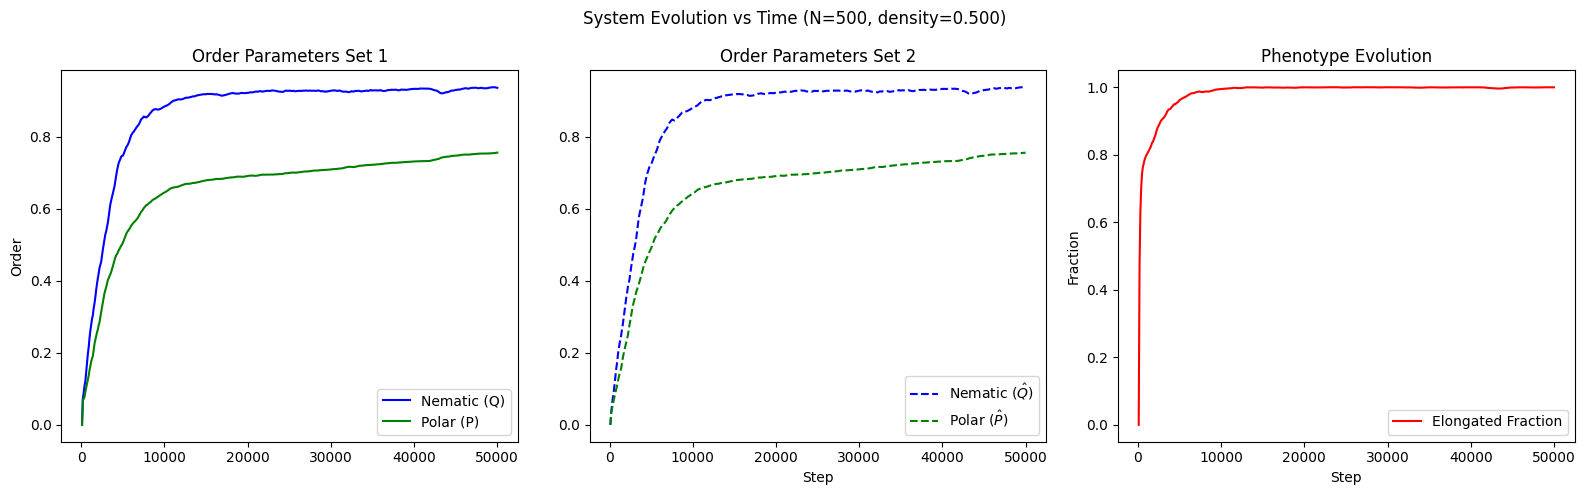

In [6]:
dens_input = input("Enter density (for example 0.50): ")
dens_nc = input("Enter number of cells (for example 10000): ")
try:
    density = float(dens_input)
    nc = int(dens_nc)
except ValueError:
    print("Error")
    exit()
df = get_order_parameter_data(num_cells=nc, dens=density)
#df.to_csv("{density_folder}/ph_vs_time.csv", index=False)
plot_order_parameters_evolution(df, dens=density, num_cells=nc)

### N=500

We can see how is the order parameters evolution for each cell density in the case of N=500:

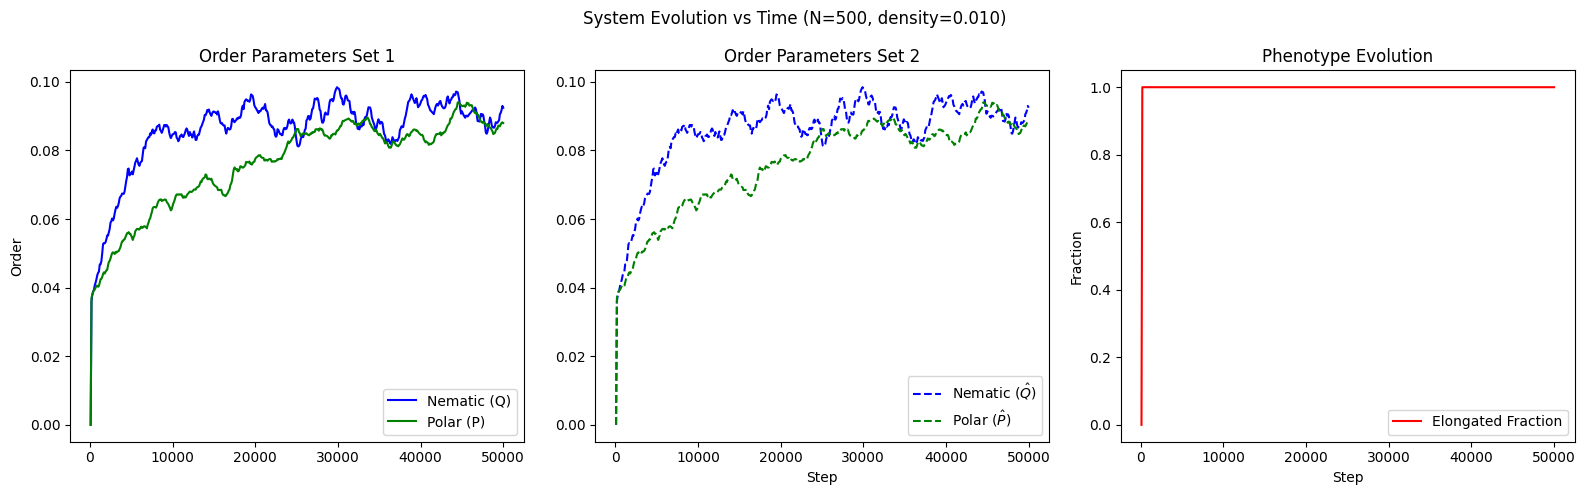

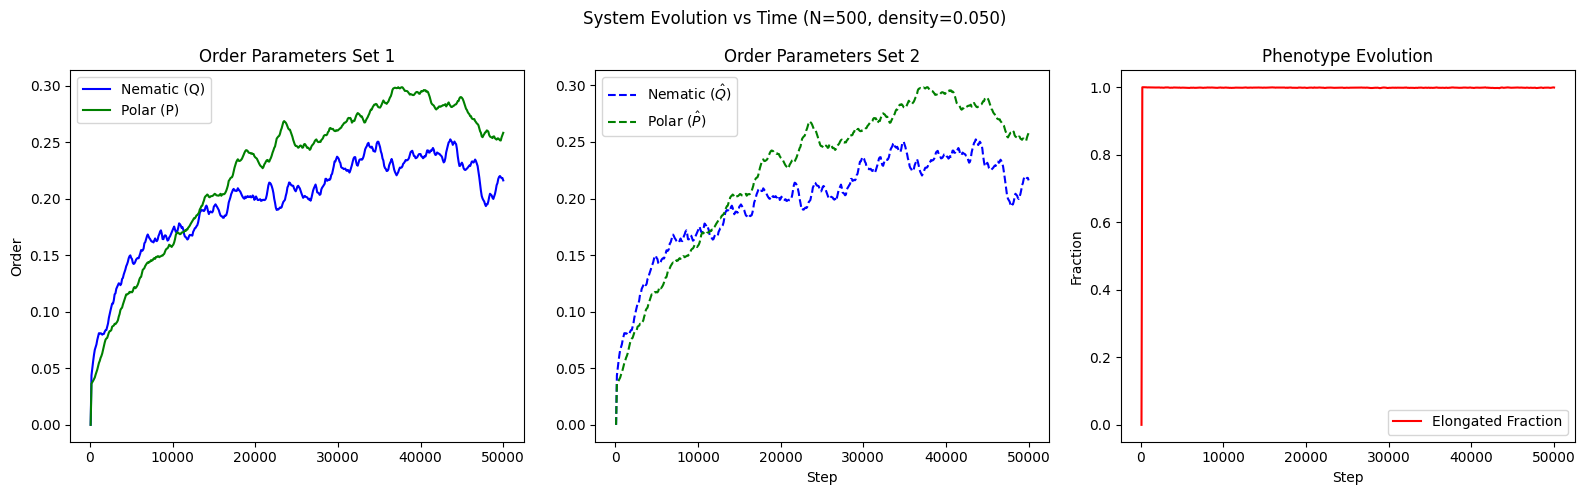

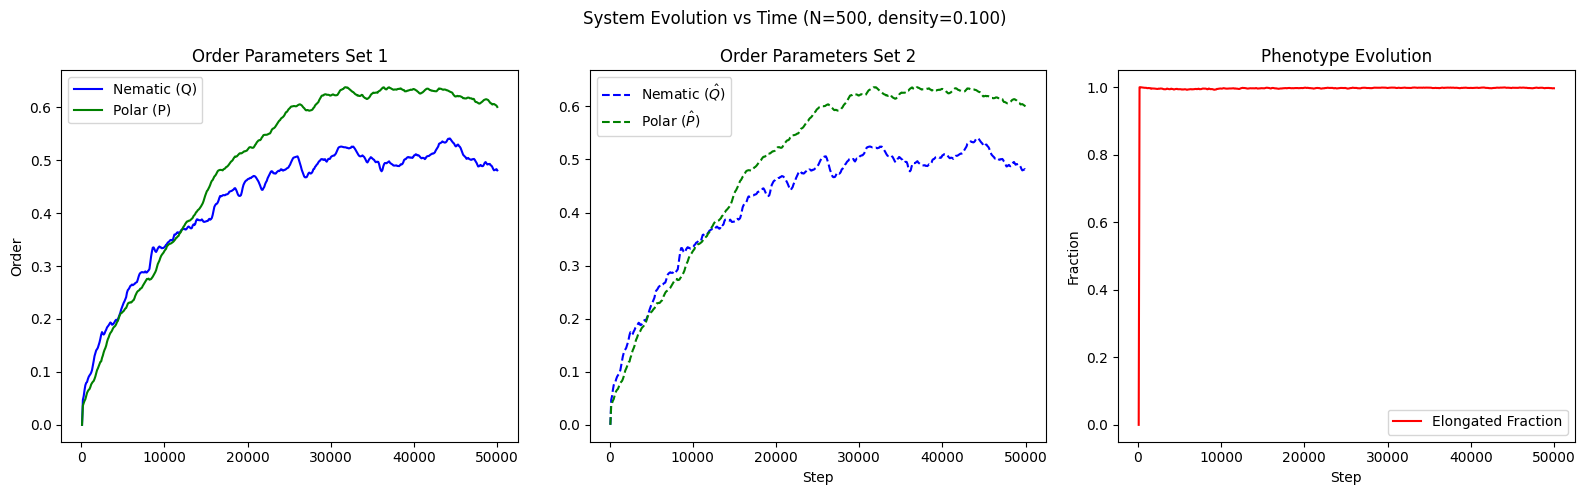

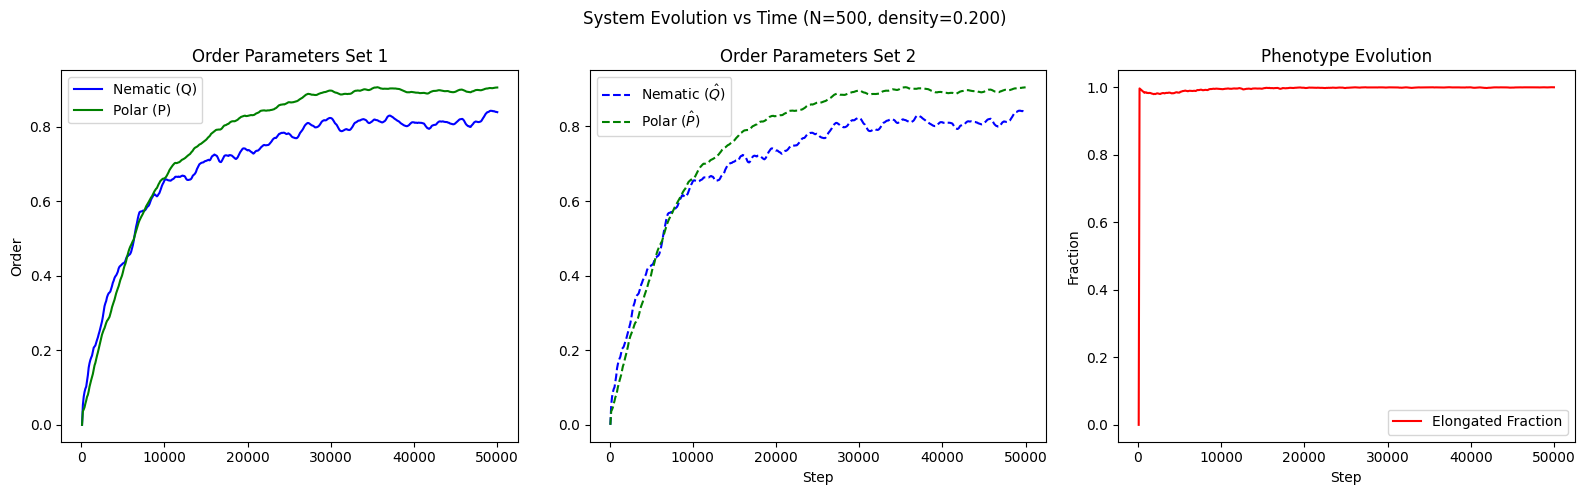

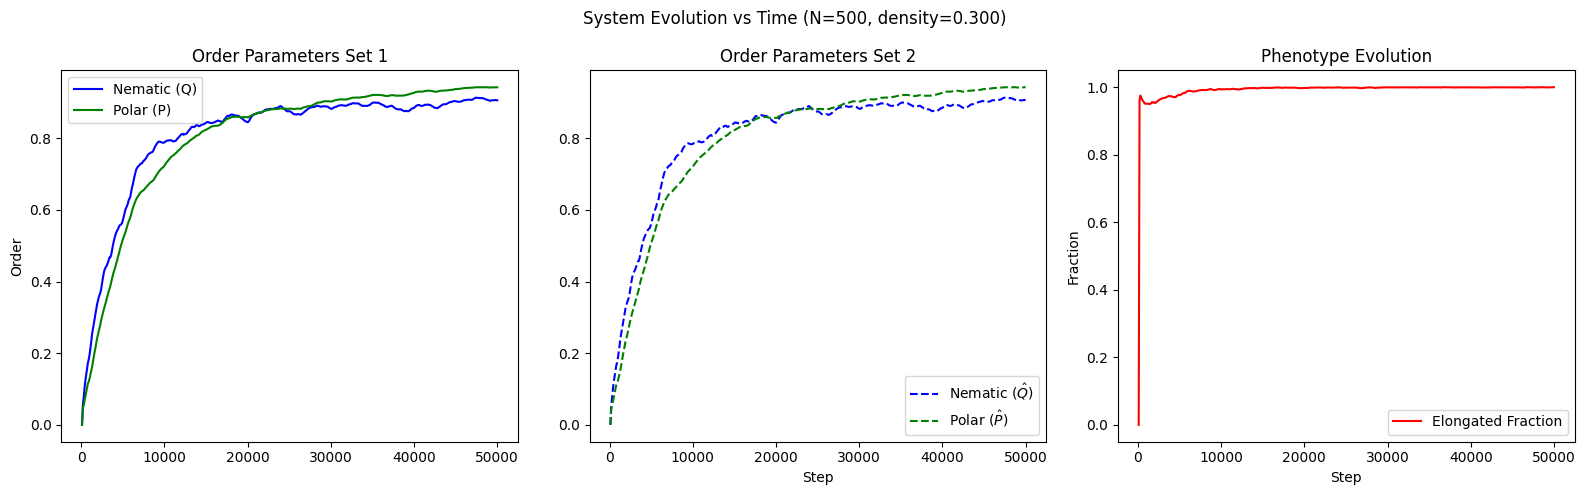

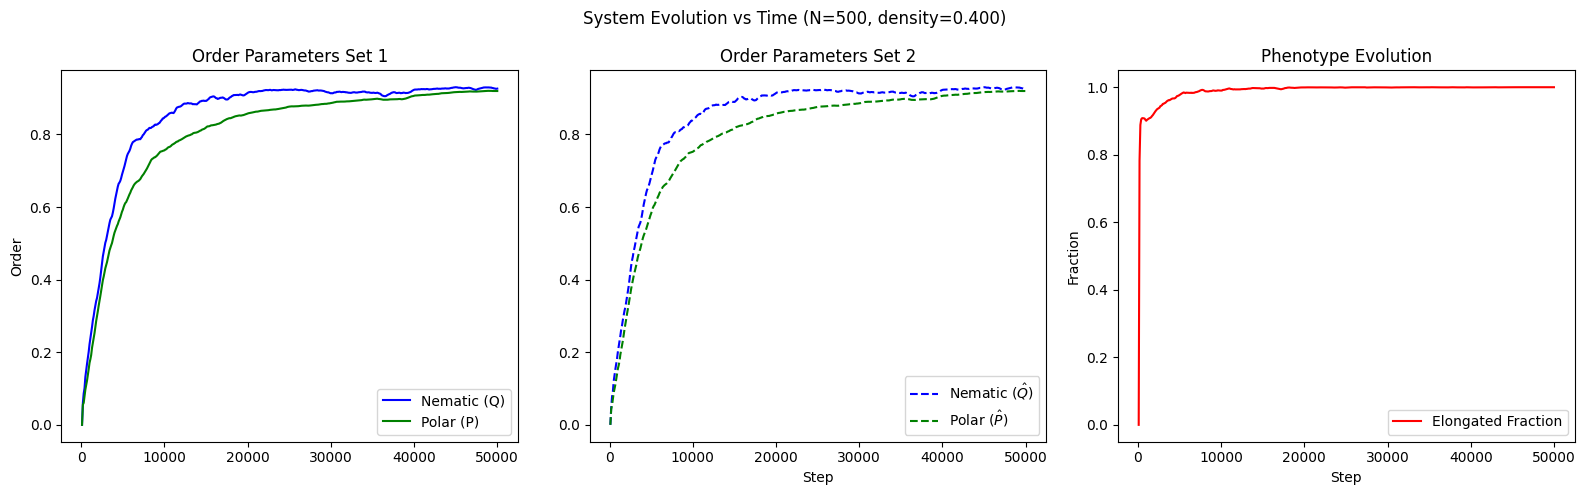

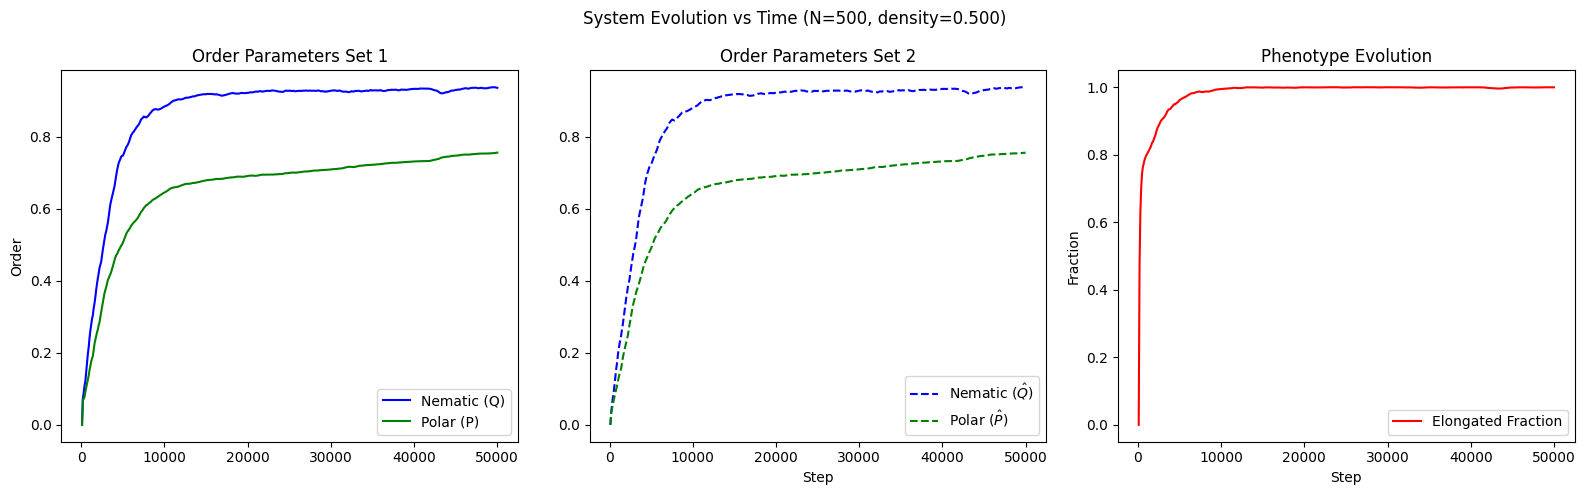

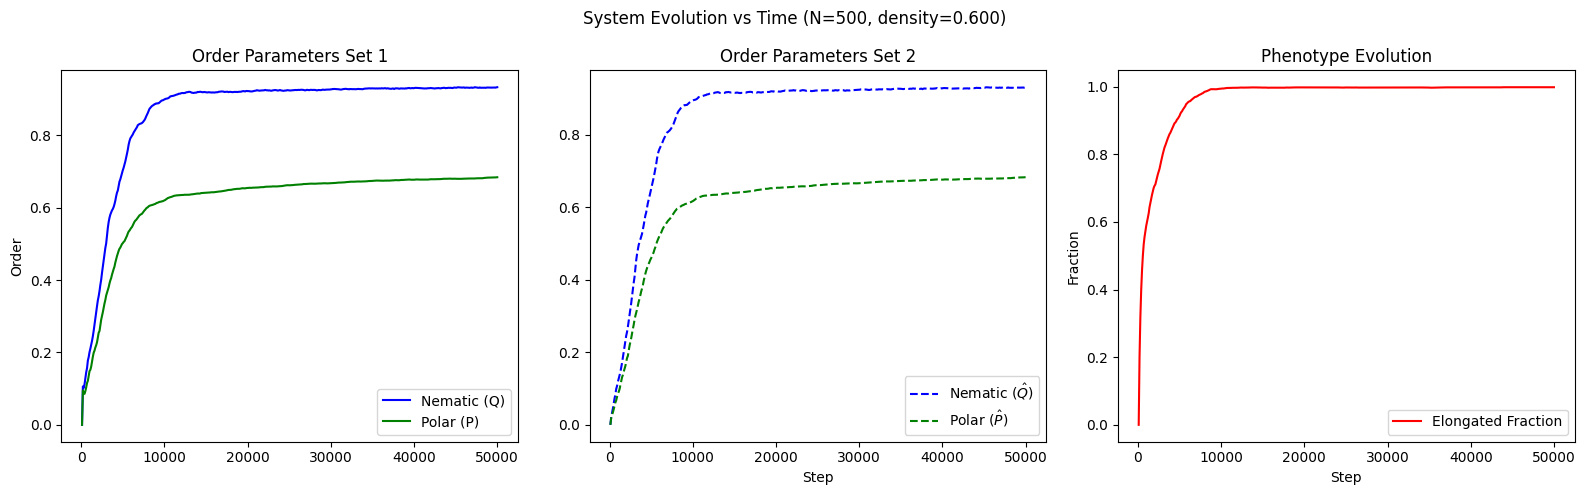

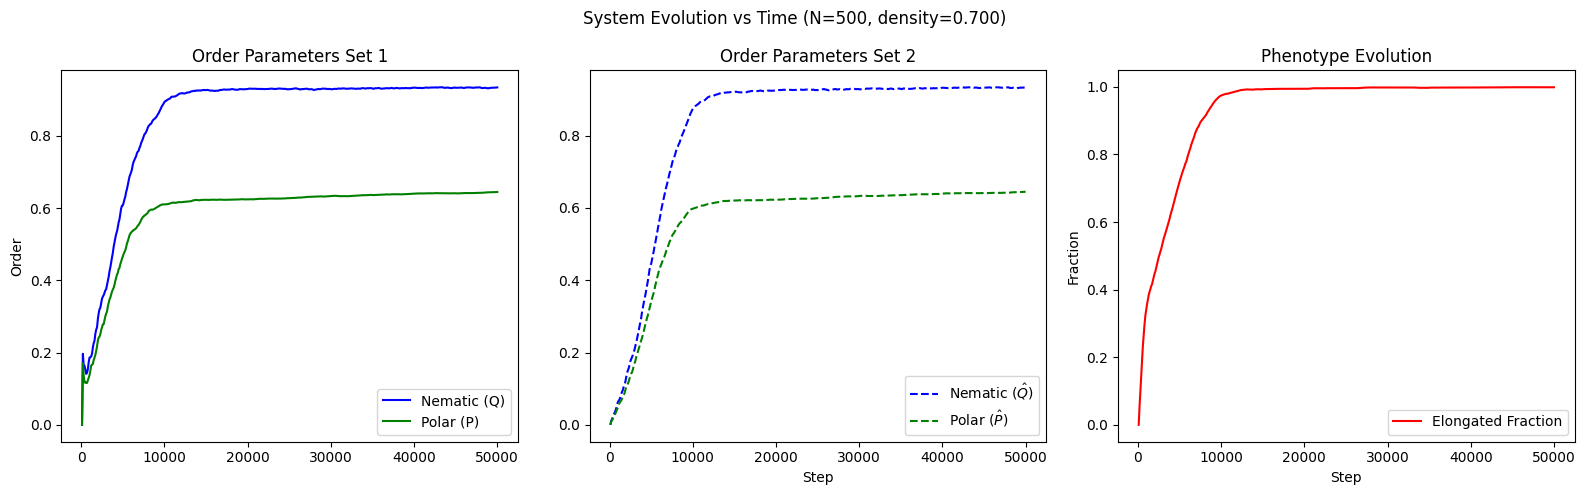

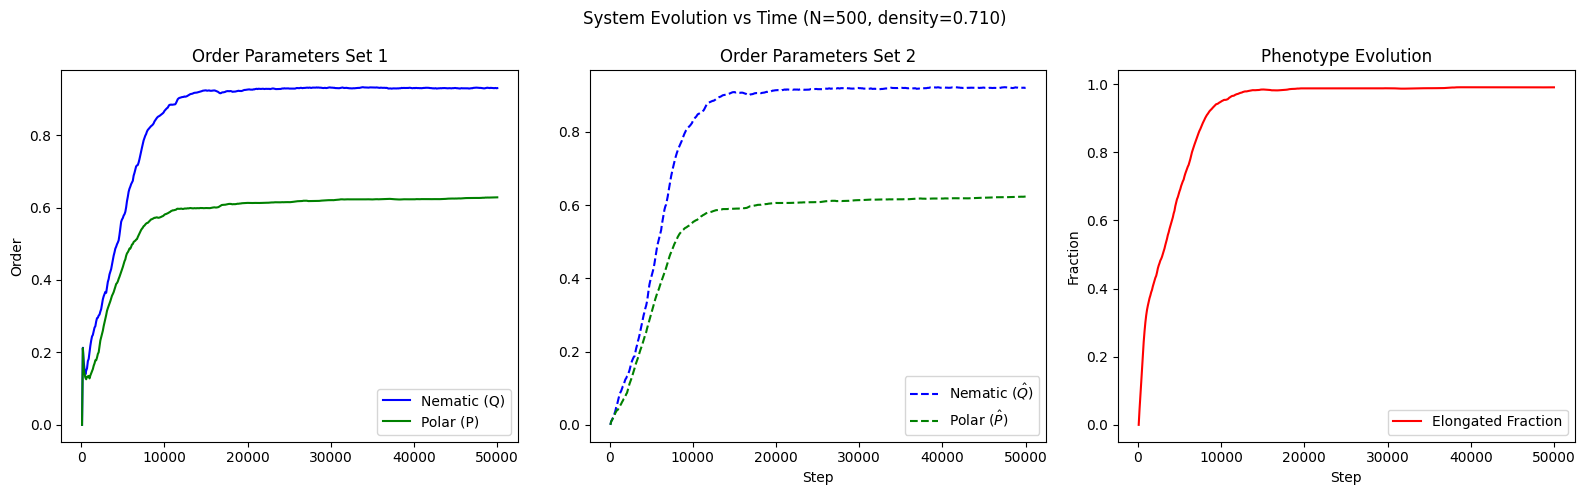

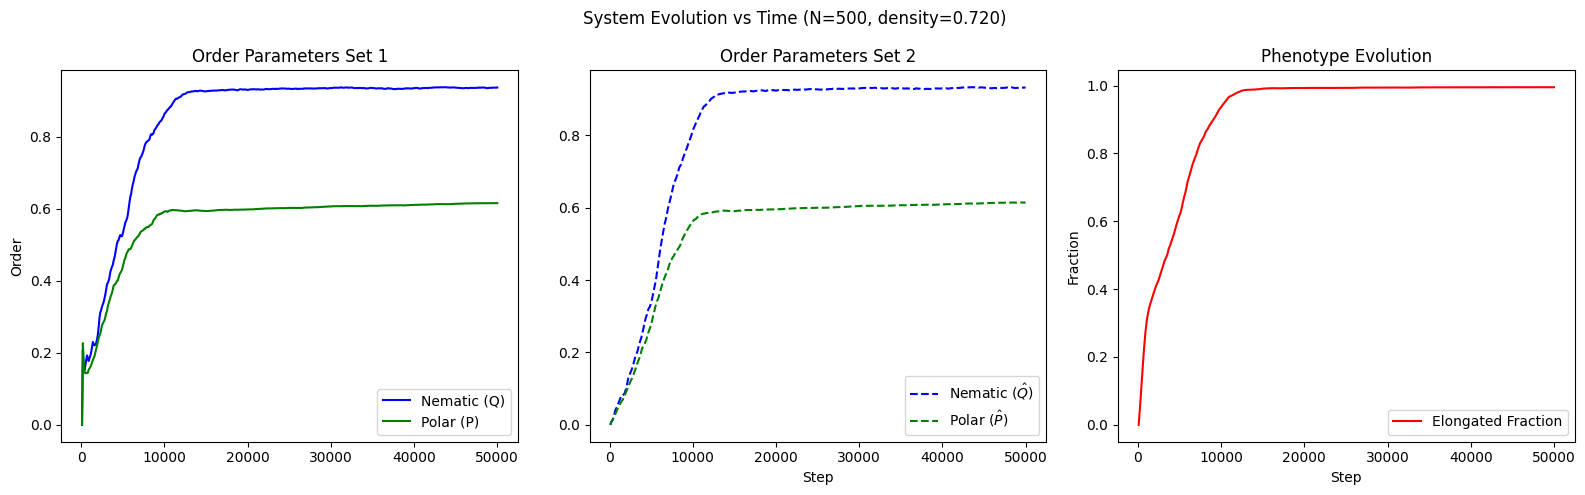

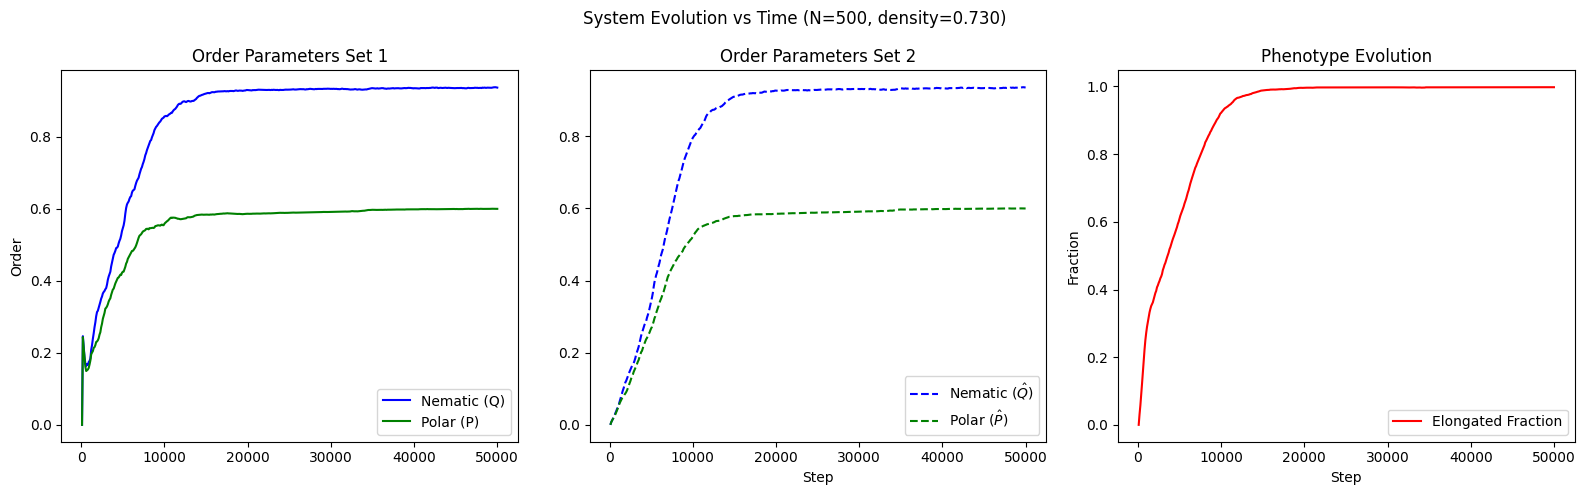

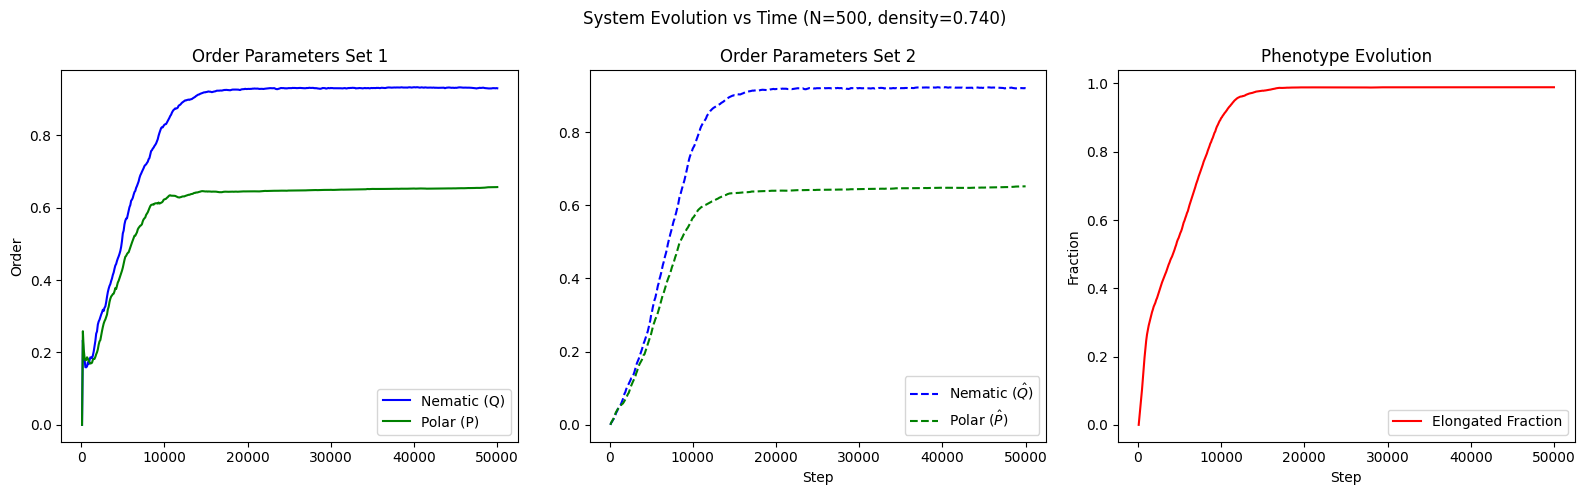

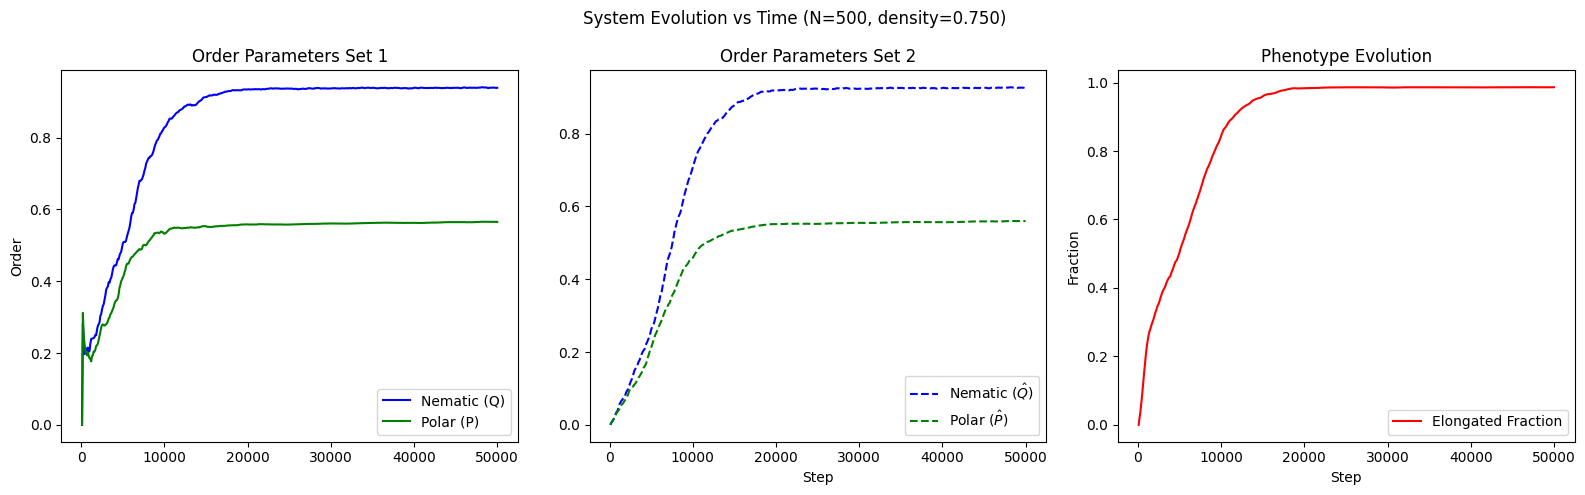

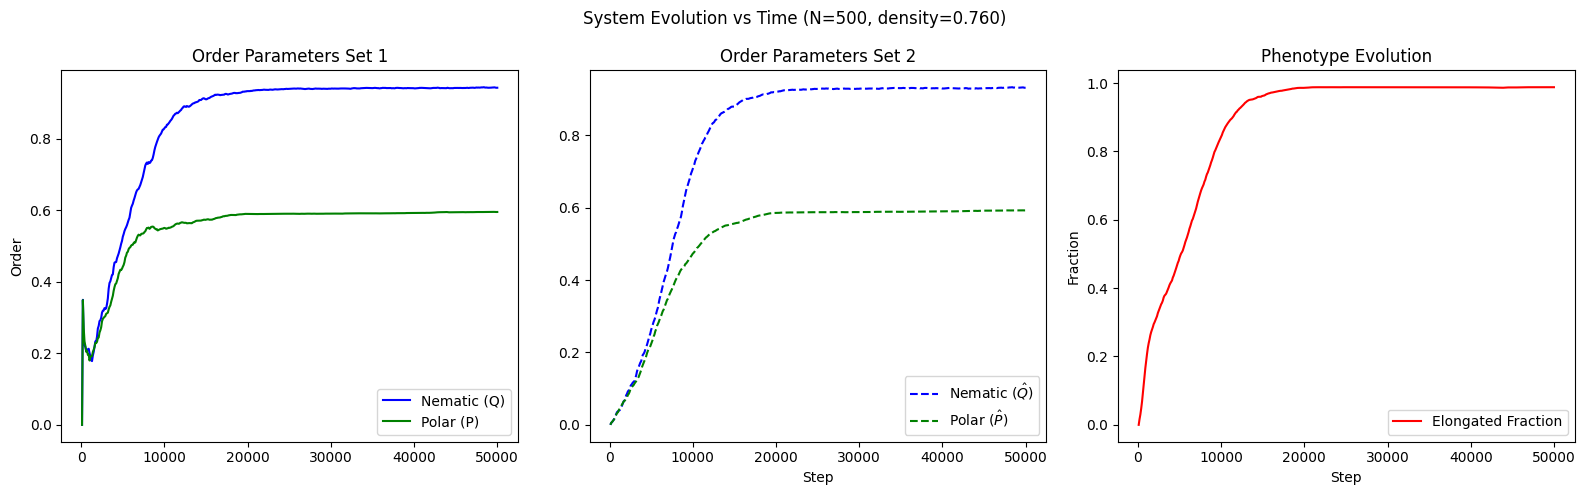

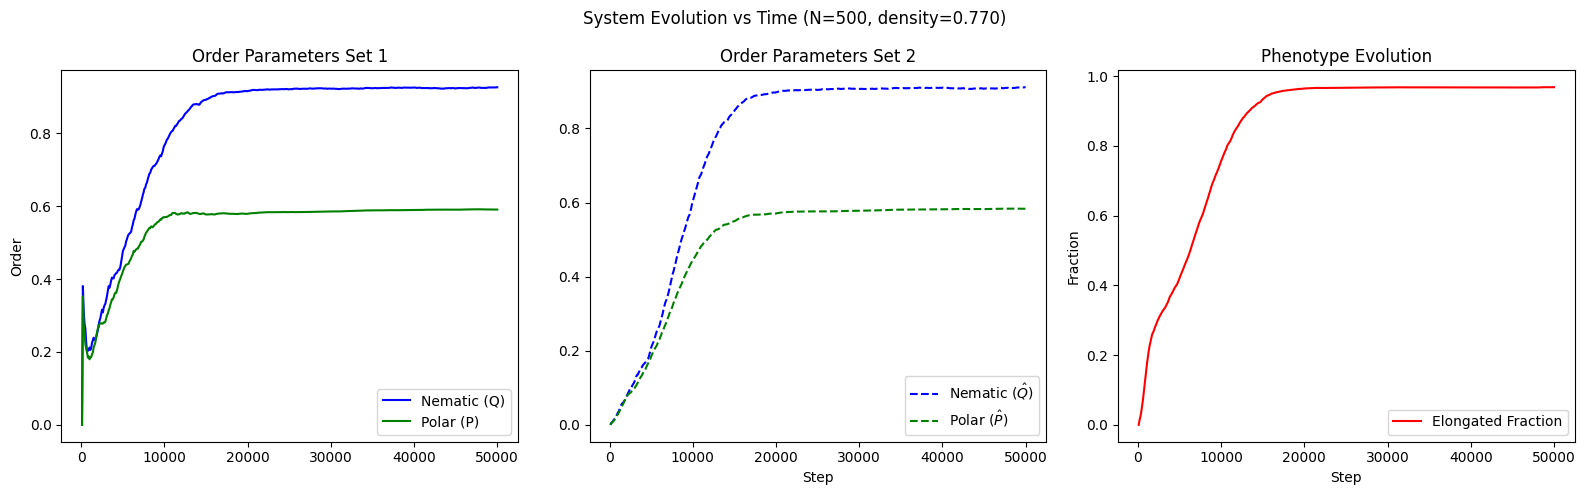

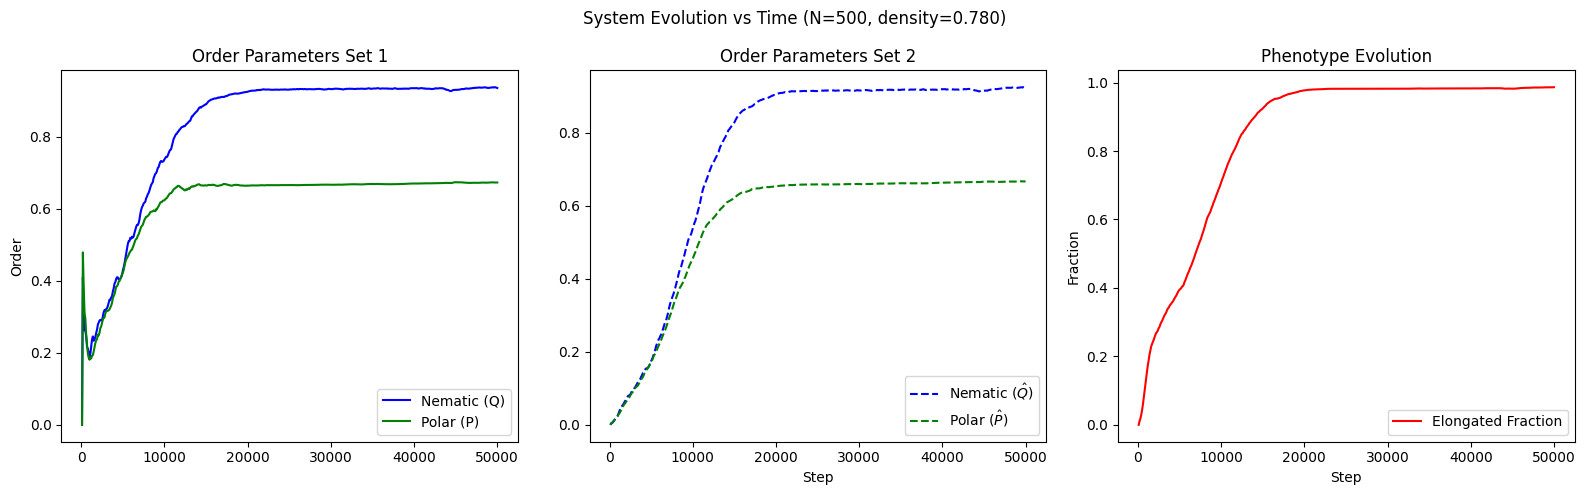

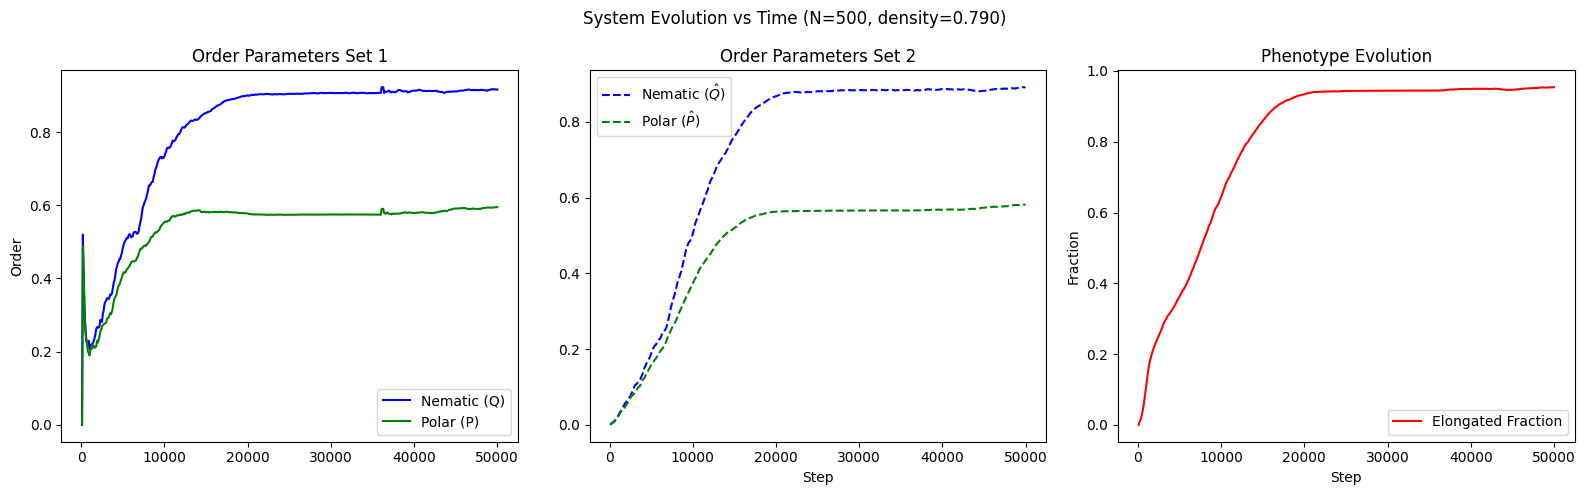

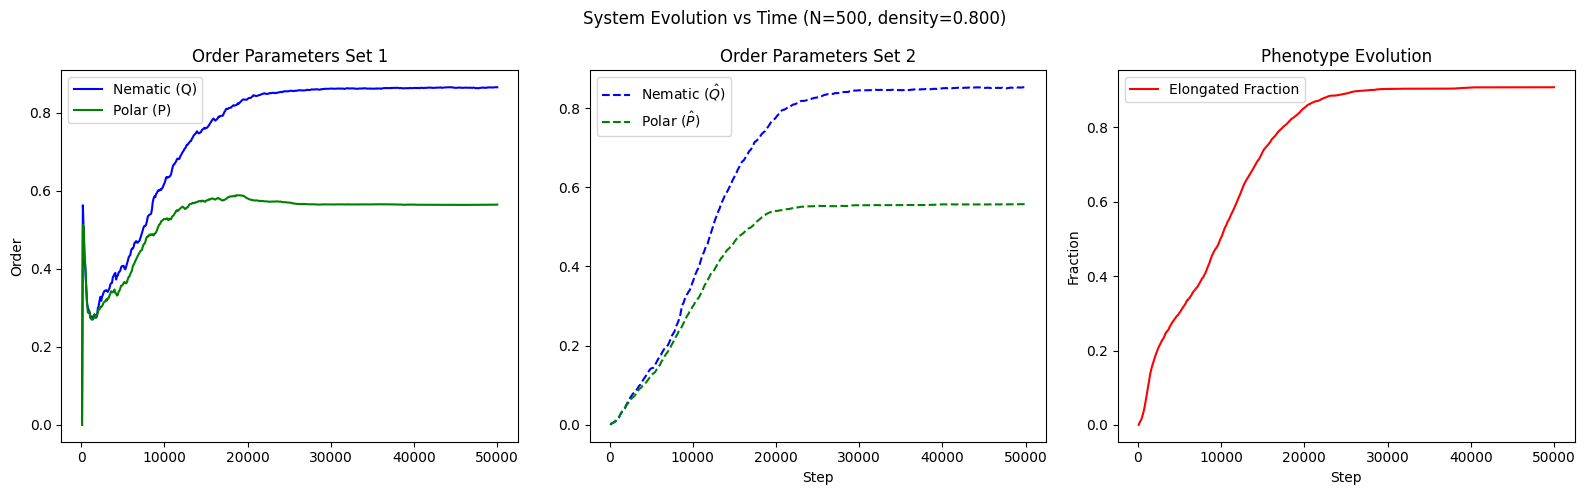

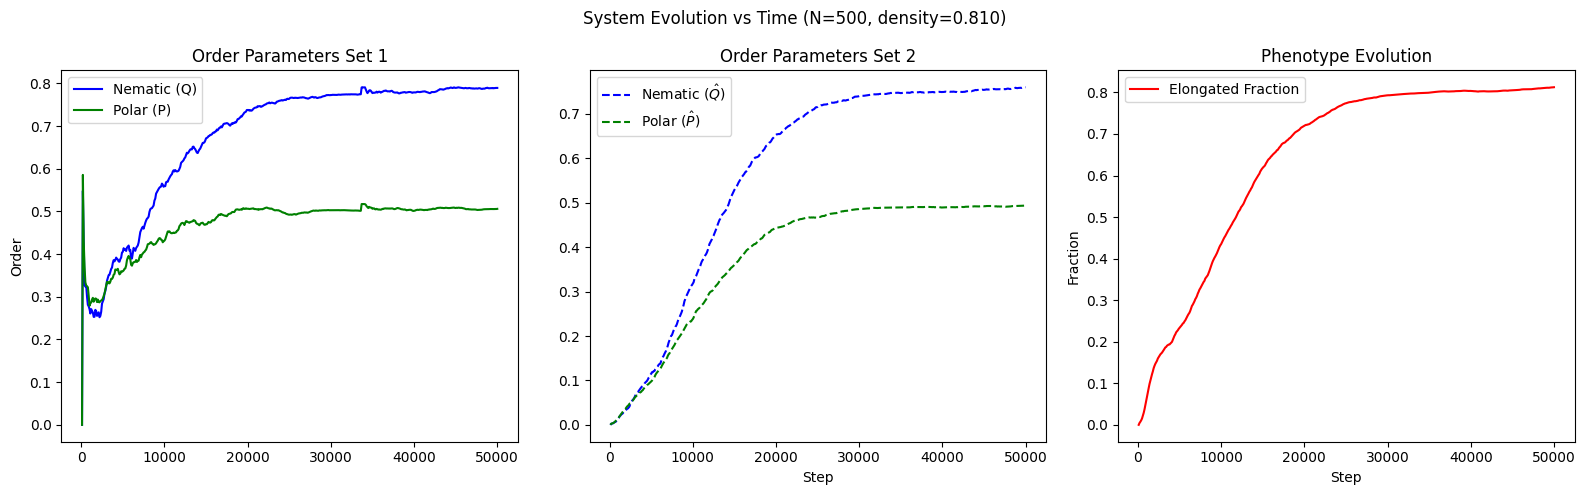

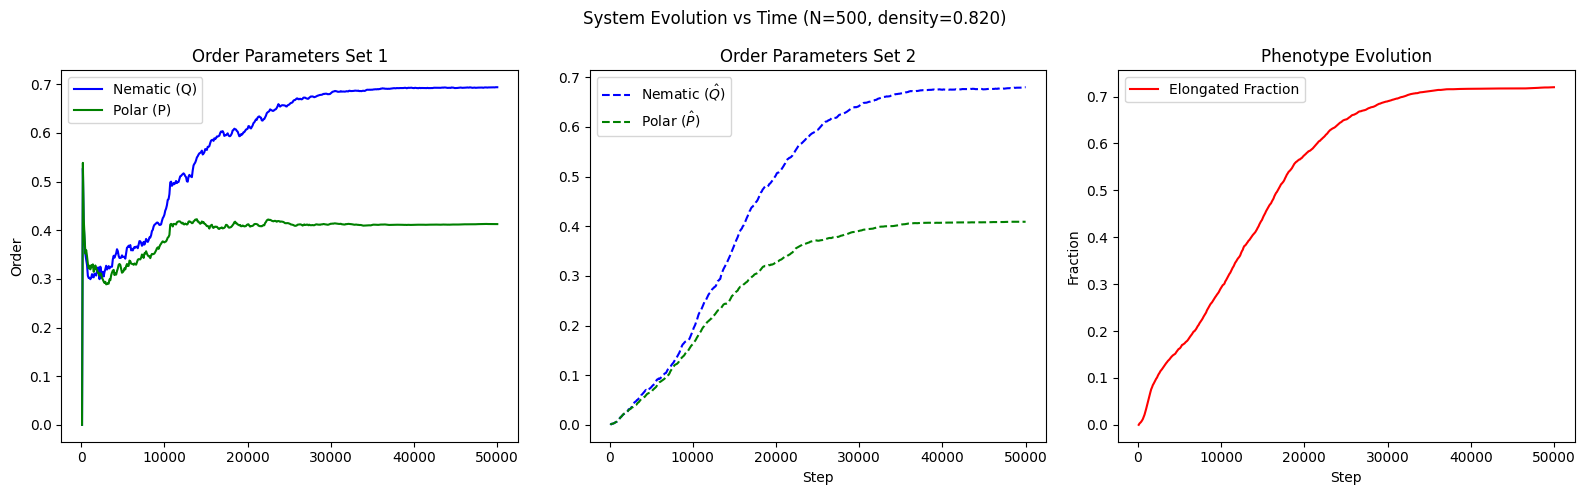

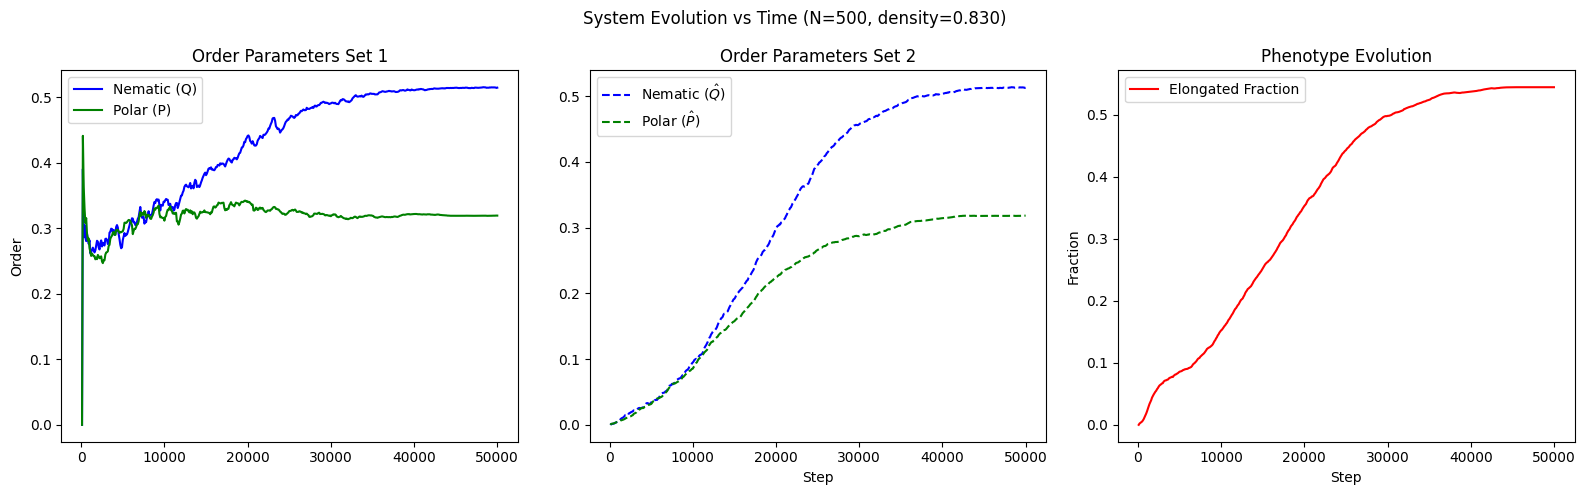

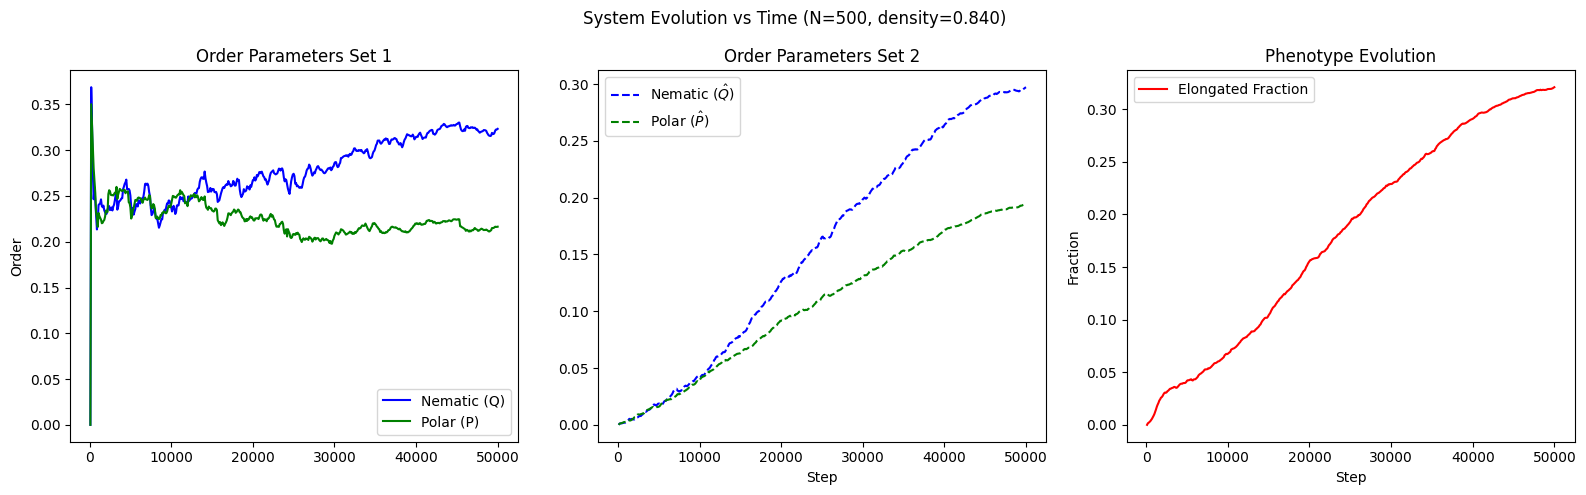

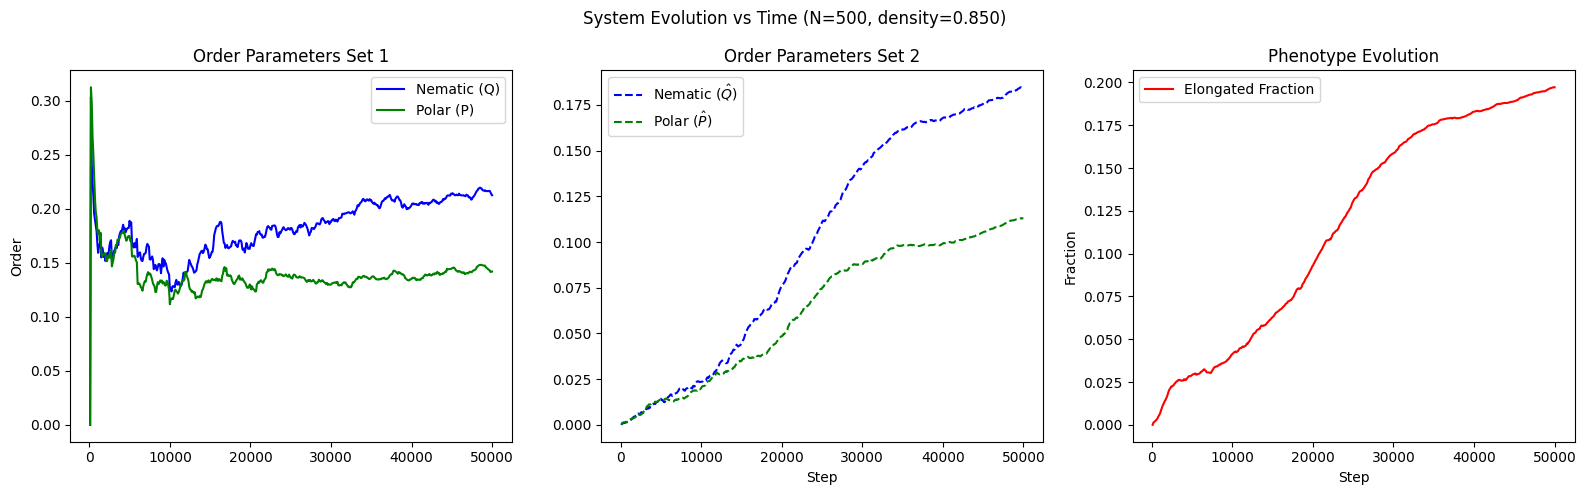

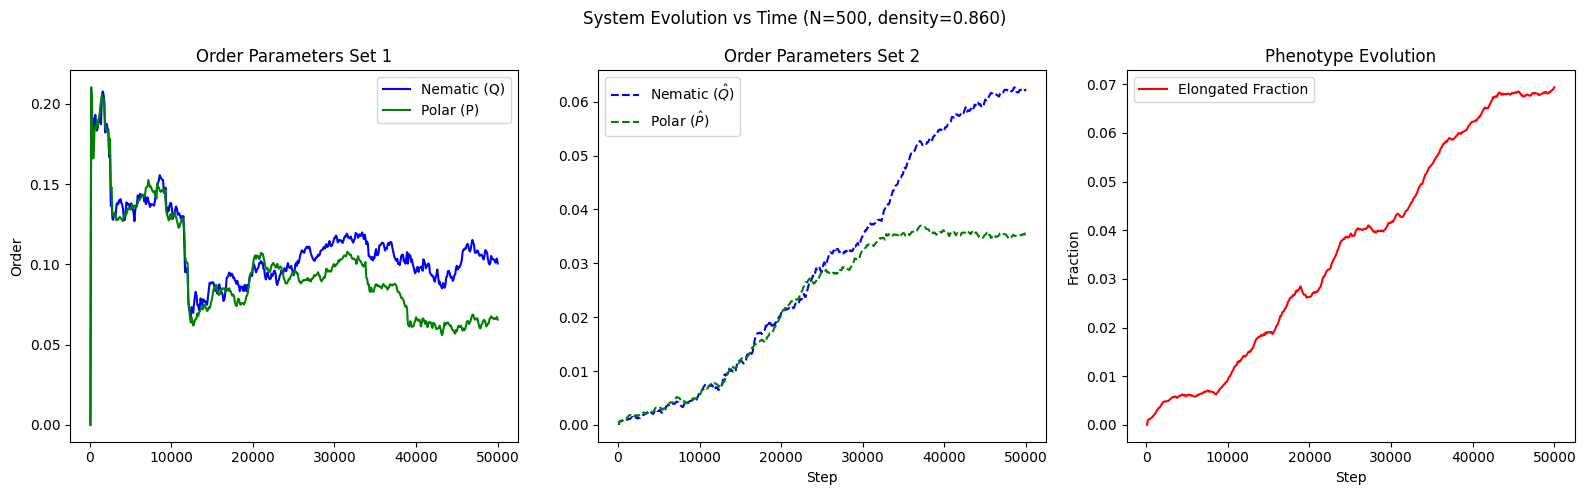

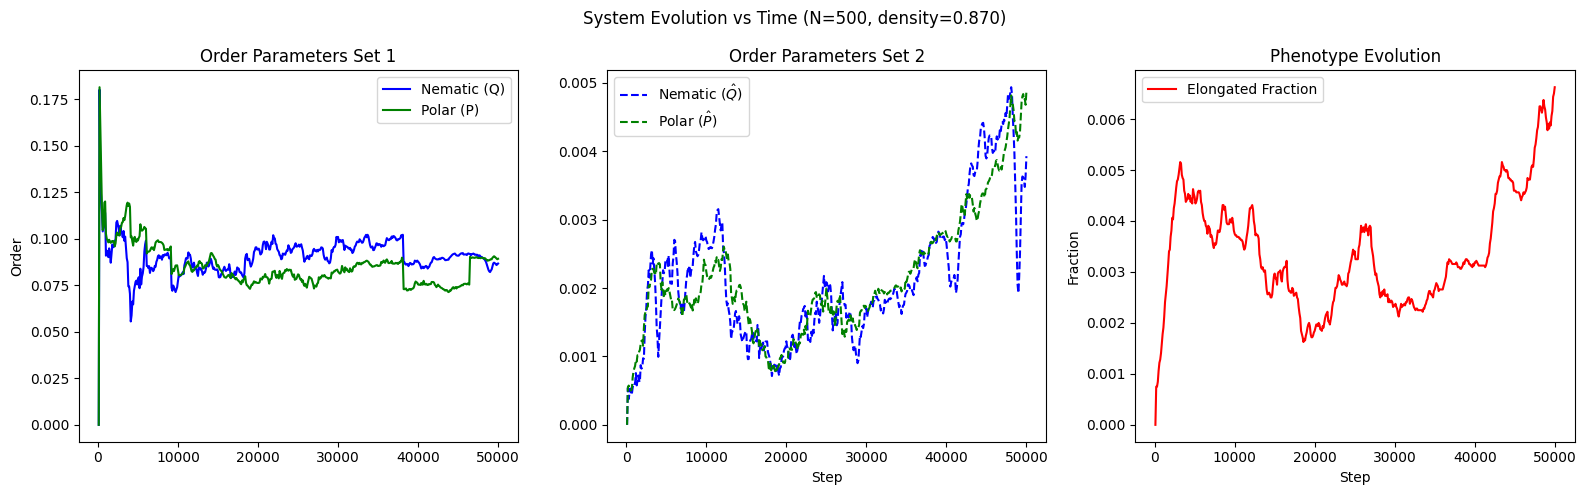

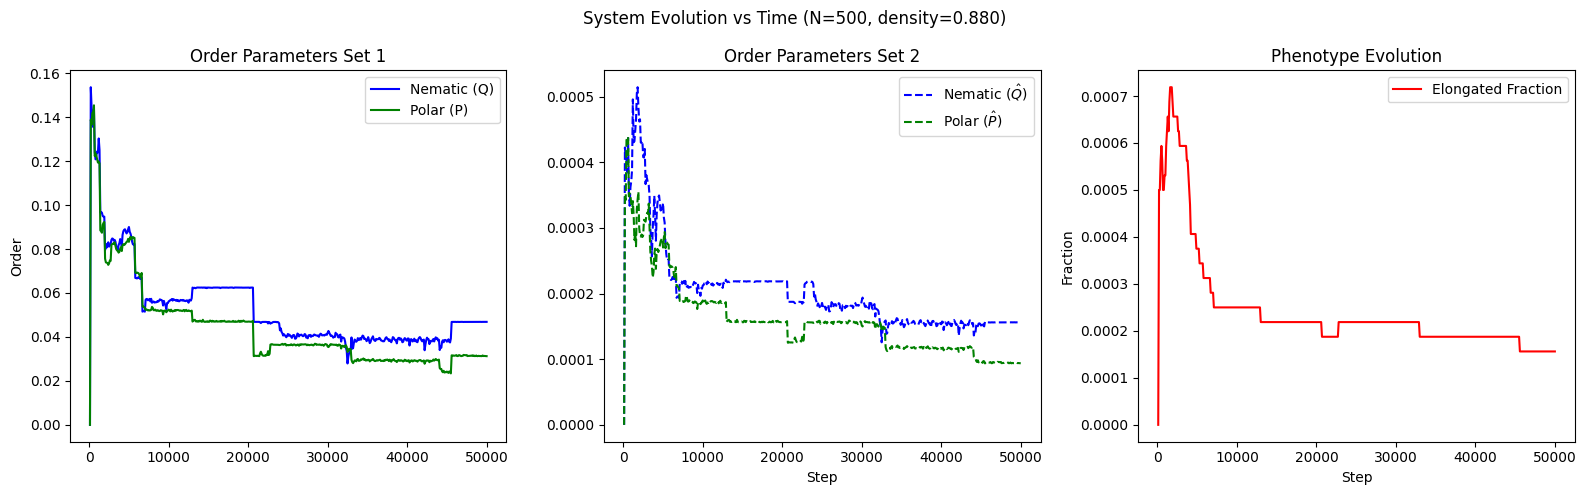

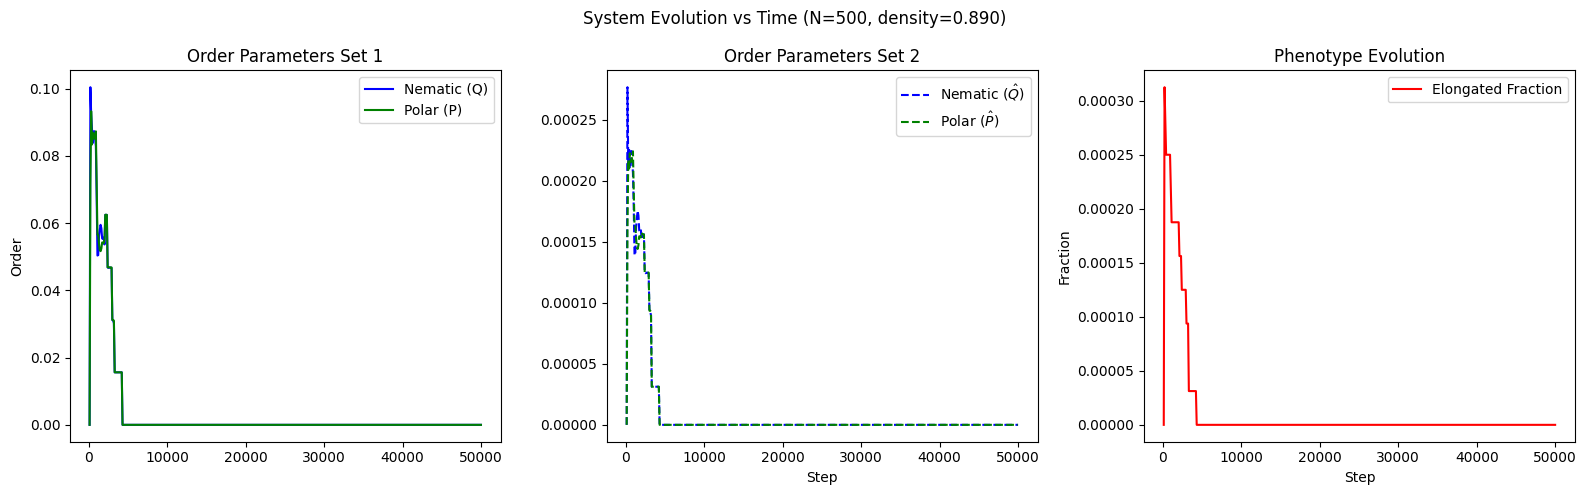

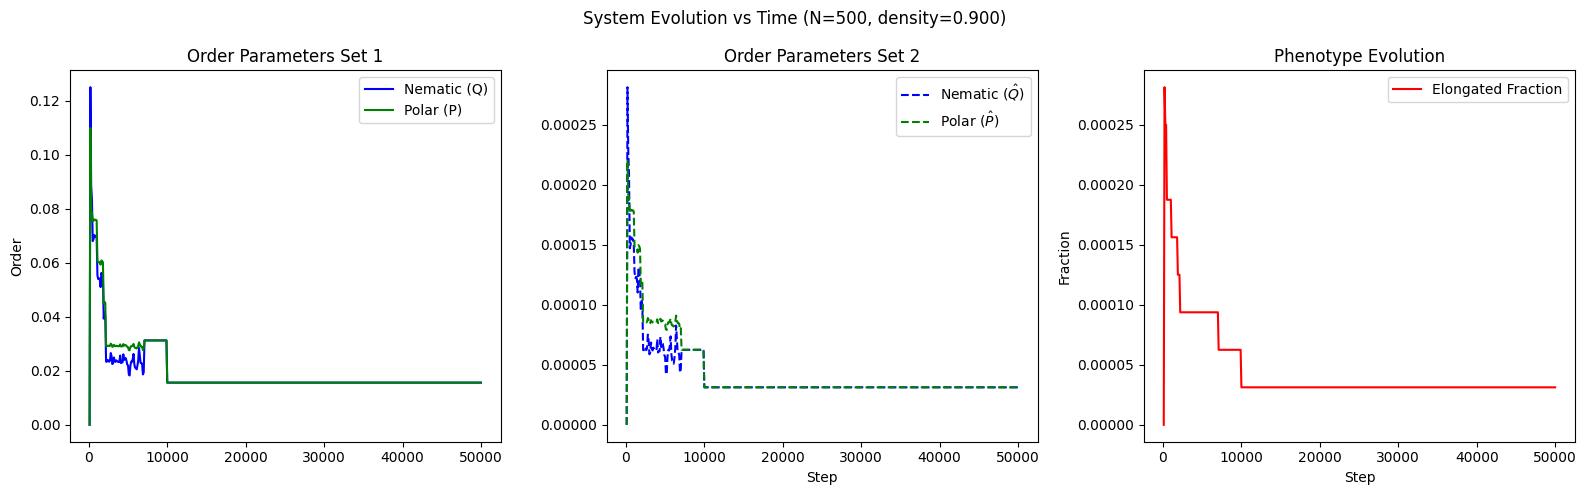

In [7]:
# Number of cells
number_of_cells = 500
# Create a list with the densities
density_list = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77, 0.78, 0.79, 0.8, 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87, 0.88, 0.89, 0.9]

for rho in density_list:
    # Obtain data
    df_rho = get_order_parameter_data(num_cells=number_of_cells, dens=rho)
        
    # Plot
    plot_order_parameters_evolution(df_rho, dens=rho, num_cells=number_of_cells)

## Steady State

Now we can plot how the final order parameters change with the density.

### Creation of useful functions

First we create a function to calculate the order parameters of the last step, saving the mean and the standard deviation.

In [8]:
def get_op_seed_stats(num_cells, dens, final_fraction=final_fraction, force_recompute=False):
    """
    Calculates the temporal average of each seed in the steady state.
    If the file 'op_seed_averages_rho_X.csv' already exists, we load it.

    Parameters
    ----------
    num_cells : int
        Number of cells in the simulation.
    dens : float
        Cell density used in the simulation.
    final_fraction : float, optional
        Fraction of final time steps to average over (e.g., 0.1 for last 10%).
        If 0.0 (default), only the last step is used.
    force_recompute : bool
        A flag to determine if we have to recompute everything although 
        there already exists a file.

    Returns
    -------
    df_seeds : pandas.DataFrame
        DataFrame with the mean of each seed.
    """
    num_cells_folder = f"N={num_cells:_}"
    # Setup output directory for order parameters
    output_dir = CONFIG["base_output_path"] / num_cells_folder / "order_parameters" / "seed_stats"
    output_dir.mkdir(parents=True, exist_ok=True)
    
    csv_path = output_dir / f"op_seed_averages_rho_{dens:.3f}.csv"

    # If it exists, load it
    if csv_path.exists() and not force_recompute:
        return pd.read_csv(csv_path)

    # Get the seeds for this N
    rng_seeds = get_seeds_for_N(num_cells)
    
    # Find the last step for the first seed
    # CAUTION: We assume every seed reached the same final step
    last_step = 100
    for tic in range(100, CONFIG["max_step"], CONFIG["step"]):
        file_check = (CONFIG["base_data_path"] / num_cells_folder / 
                     f"{dens:.3f}".replace(".", "_") / "dat_order_parameters" / 
                     f"op_culture_initial_number_of_cells={num_cells}_density={dens}_"
                     f"force=Anisotropic_Grosmann_k=3.33_gamma=3_With_Noise_eta=0.033_With_Shrinking_"
                     f"rng_seed={rng_seeds[0]}_step={tic:05}.dat")
        if not file_check.exists():
            break
        last_step = tic
    
    # Define steady state steps using the final fraction
    all_steps = list(range(100, last_step + CONFIG["step"], CONFIG["step"]))
    n_final = max(1, int(len(all_steps) * final_fraction))
    steps_to_use = all_steps[-n_final:]

    seed_results = []
    raw_data_base = CONFIG["base_data_path"] / num_cells_folder / f"{dens:.3f}".replace(".", "_") / "dat_order_parameters"

    # Iterate through every seed
    for seed in rng_seeds:
        seed_data = []
        for s in steps_to_use:
            file_name = (f"op_culture_initial_number_of_cells={num_cells}_density={dens}_"
                         f"force=Anisotropic_Grosmann_k=3.33_gamma=3_With_Noise_eta=0.033_"
                         f"With_Shrinking_rng_seed={seed}_step={s:05}.dat")
            path = raw_data_base / file_name
            
            if path.exists():
                # Read relevant columns and calculate mean of this step
                df_step = pd.read_csv(path, usecols=["nematic", "polar", "nematic_2", "polar_2", "fraction_elongated"])
                seed_data.append(df_step.mean().values)
        
        if seed_data:
            # Calculate temporal average for this specific seed
            mean_seed = np.mean(seed_data, axis=0)
            seed_results.append([seed] + list(mean_seed))

    # Convert results to DataFrame
    df_seeds = pd.DataFrame(seed_results, columns=["seed", "nematic", "polar", "nematic_2", "polar_2", "fraction_elongated"])
    
    # Store for future use
    df_seeds.to_csv(csv_path, index=False)
    return df_seeds

And a function to get the summary of the steady states.

In [9]:
def get_op_steady_state_summary(num_cells, density_list, final_fraction=final_fraction):
    """
    Combines the averages of every seed for all densities for order parameters.

    Parameters
    ----------
    num_cells : int
        Number of cells in the simulation.
    density_list : list of float
        List of cell densities used in the simulation.
    final_fraction : float, optional
        Fraction of final time steps to average over (e.g., 0.1 for last 10%).
        If 0.0 (default), only the last step is used.

    Returns
    -------
    df_summary : pandas.DataFrame
        Dataframe with the summary of order parameters.
    """
    summary_rows = []
    
    for dens in density_list:
        # Obtain the dataframe with one row per seed
        # This calls the function we defined previously for OPs
        df_seeds = get_op_seed_stats(num_cells, dens, final_fraction)
        
        if df_seeds.empty:
            continue
            
        # Calculate mean and std over the seeds (realizations)
        row = {
            "density": dens,
            # Means
            "nematic": df_seeds["nematic"].mean(),
            "polar": df_seeds["polar"].mean(),
            "nematic_2": df_seeds["nematic_2"].mean(),
            "polar_2": df_seeds["polar_2"].mean(),
            "fraction_elongated": df_seeds["fraction_elongated"].mean(),
            # Standard deviations (for variance and error bars)
            "nematic_std": df_seeds["nematic"].std(),
            "polar_std": df_seeds["polar"].std(),
            "nematic_2_std": df_seeds["nematic_2"].std(),
            "polar_2_std": df_seeds["polar_2"].std(),
            "fraction_elongated_std": df_seeds["fraction_elongated"].std(),
            # Sample size
            "n_realizations": len(df_seeds)
        }
        summary_rows.append(row)
    
    # Create the final dataframe
    df_summary = pd.DataFrame(summary_rows)
    
    # Define the save path within the order_parameters subfolder
    summary_path = (CONFIG["base_output_path"] / f"N={num_cells:_}" / 
                    "order_parameters" / f"op_steady_state_summary_N={num_cells}.csv")
    
    # Ensure directory exists and save
    summary_path.parent.mkdir(parents=True, exist_ok=True)
    df_summary.to_csv(summary_path, index=False)
    
    return df_summary

Now we use this function to plot the steady states. We will need to create 2 DataFrames with the information of the mean and standard deviation for every density and give them to the plot function.

In [10]:
def plot_op_steady_state(df_summary, num_cells):
    """
    Plots the mean and variance of all order parameters (Standard and Hat)
    and the elongated fraction in the steady state.

    Parameters
    ----------
    df_summary : pandas.DataFrame
        DataFrame with aggregated order parameter statistics.
    num_cells : int
        Number of cells in the simulation.
    """
    # Cambiamos a 3 filas de gráficos y aumentamos el alto de la figura
    fig, axes = plt.subplots(3, 2, figsize=(12, 12), sharex=True)
    
    # Standard OPs in the first row, Hat OPs in the second row
    metrics = ["nematic", "polar", "nematic_2", "polar_2"]
    colors = ["blue", "green", "blue", "green"]
    labels = ["Nematic (Q)", "Polar (P)", r"Nematic ($\hat{Q}$)", r"Polar ($\hat{P}$)"]
    
    # Plot Standard Order Parameters (Top Left: Mean, Top Right: Variance)
    for i in range(2):
        metric_name = metrics[i]
        std_col = f"{metric_name}_std"
        
        # Calculate standard error (SEM = std / sqrt(N_realizations))
        sem = df_summary[std_col] / np.sqrt(df_summary["n_realizations"])
        
        # Plot mean
        axes[0, 0].errorbar(df_summary["density"], df_summary[metric_name], yerr=sem, 
                            fmt='o-', color=colors[i], label=labels[i], capsize=3)
        
        # Plot variance (std squared)
        axes[0, 1].plot(df_summary["density"], df_summary[std_col]**2, 
                        'o--', color=colors[i], label=f"Var({labels[i]})")

    # Plot Hat Order Parameters (Middle Left: Mean, Middle Right: Variance)
    for i in range(2, 4):
        metric_name = metrics[i]
        std_col = f"{metric_name}_std"
        
        sem = df_summary[std_col] / np.sqrt(df_summary["n_realizations"])
        
        # Plot mean
        axes[1, 0].errorbar(df_summary["density"], df_summary[metric_name], yerr=sem, 
                            fmt='o-', color=colors[i], label=labels[i], capsize=3)
        
        # Plot variance
        axes[1, 1].plot(df_summary["density"], df_summary[std_col]**2, 
                        'o--', color=colors[i], label=f"Var({labels[i]})")

    # Plot Elongated Fraction (Bottom Left: Mean, Bottom Right: Variance)
    frac_metric = "fraction_elongated"
    frac_std_col = "fraction_elongated_std"
    frac_sem = df_summary[frac_std_col] / np.sqrt(df_summary["n_realizations"])

    axes[2, 0].errorbar(df_summary["density"], df_summary[frac_metric], yerr=frac_sem, 
                        fmt='o-', color="red", label="Elongated Fraction", capsize=3)
    
    axes[2, 1].plot(df_summary["density"], df_summary[frac_std_col]**2, 
                    'o--', color="red", label="Var(Elongated Fraction)")

    # Settings
    axes[0, 0].set_title("Standard Order Parameters (Mean ± SEM)")
    axes[0, 1].set_title("Standard OPs Variance")
    axes[1, 0].set_title(r"Hat Order Parameters (Mean ± SEM)")
    axes[1, 1].set_title(r"Hat OPs Variance")
    axes[2, 0].set_title("Phenotype Fraction (Mean ± SEM)")
    axes[2, 1].set_title("Phenotype Fraction Variance")
    
    for ax in axes.flat:
        ax.set_xlabel("Density ρ")
        ax.grid(alpha=0.3)
        ax.legend(fontsize='small')

    plt.suptitle(f"Steady State Order Parameters (N={num_cells})", fontsize=16)
    plt.tight_layout()
    
    # Save using the same internal logic as the phenotypes function
    num_cells_folder = f"N={num_cells:_}"
    output_dir = CONFIG["base_graph_path"] / num_cells_folder / "order_parameters" / "op_steady_state"
    output_dir.mkdir(parents=True, exist_ok=True)
    
    plt.savefig(output_dir / f"op_steady_state_summary_N={num_cells}.png", dpi=600)
    plt.show()

### N=500

Let's see the steady state of every density and N=500.

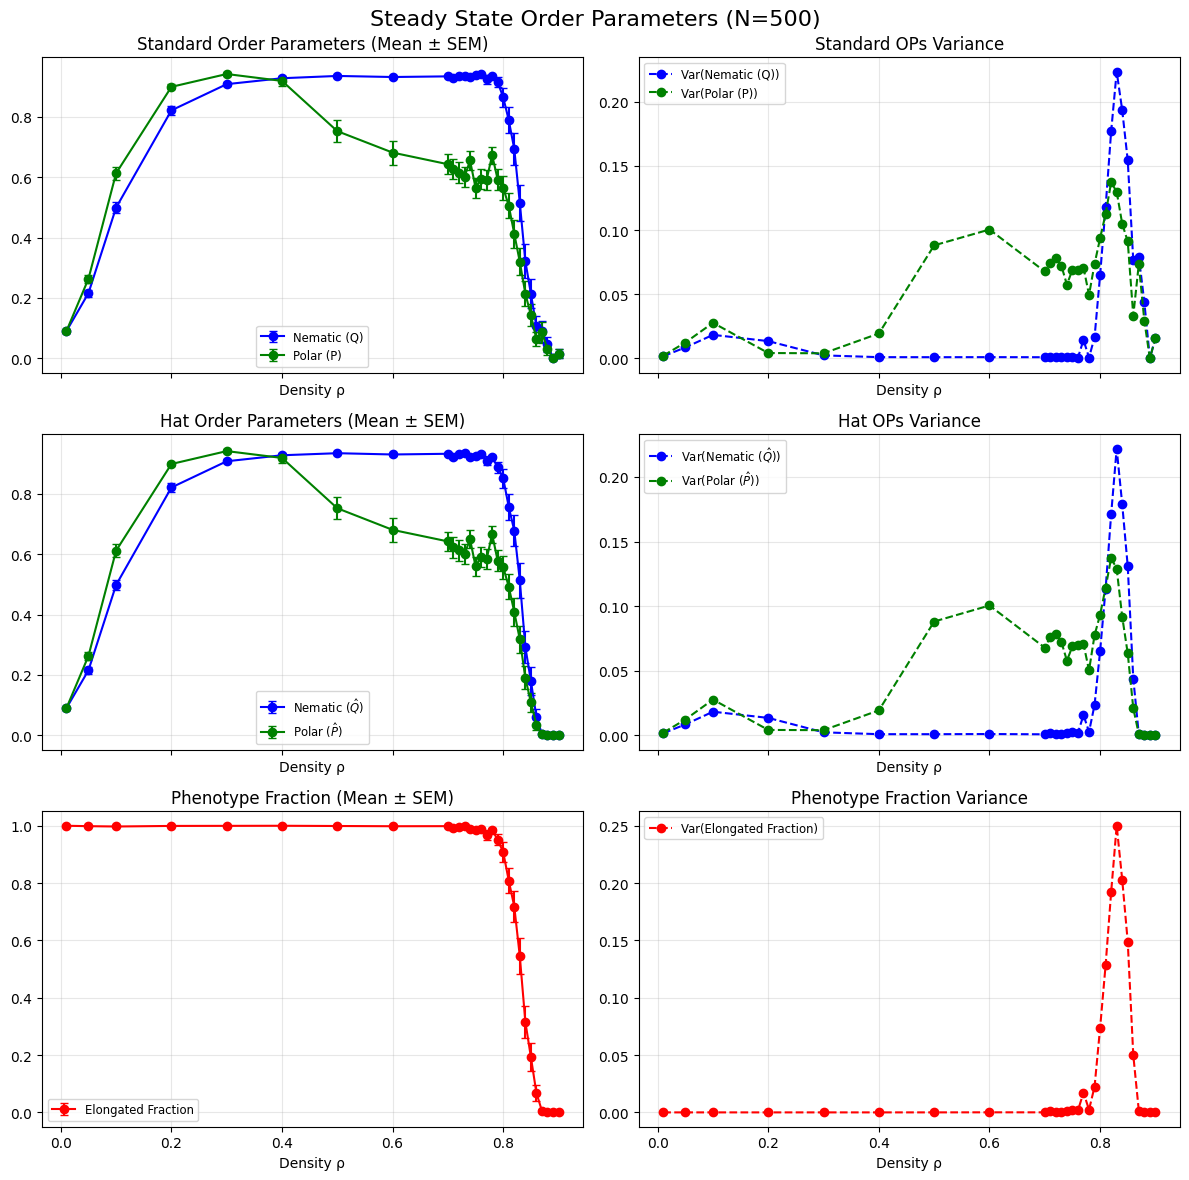

In [11]:
number_cells = 500
density_list = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77, 0.78, 0.79, 0.8, 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87, 0.88, 0.89, 0.9]

# Obtain the summary of the steady state
df_steady_500 = get_op_steady_state_summary(
    num_cells=number_cells, 
    density_list=density_list
)

# Plot
plot_op_steady_state(df_steady_500, num_cells=number_cells)

## Susceptibility

Given an order parameter $\phi$ we can study the corresponded susceptibility $\chi$:

$$ \chi = N (\langle \phi^2 \rangle - \langle \phi \rangle^2)$$

This is a very important quantity because, in the thermodynamic limit, it has to diverge (or have a sharp peak) at the critical point.


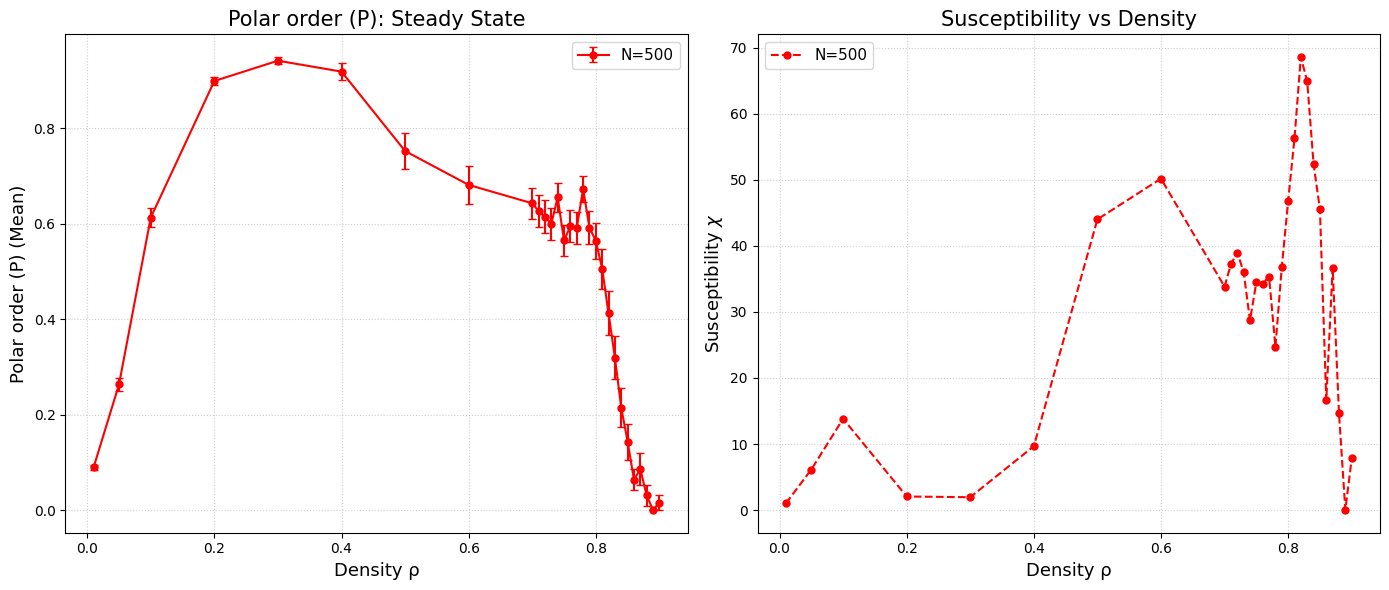

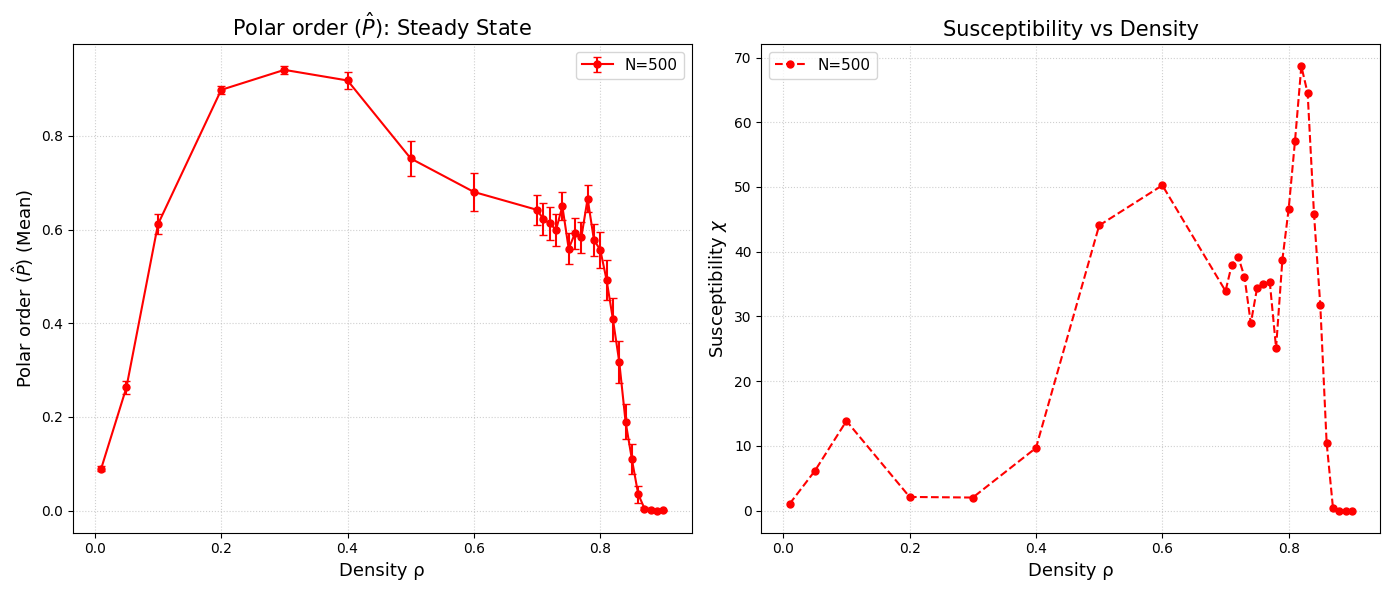

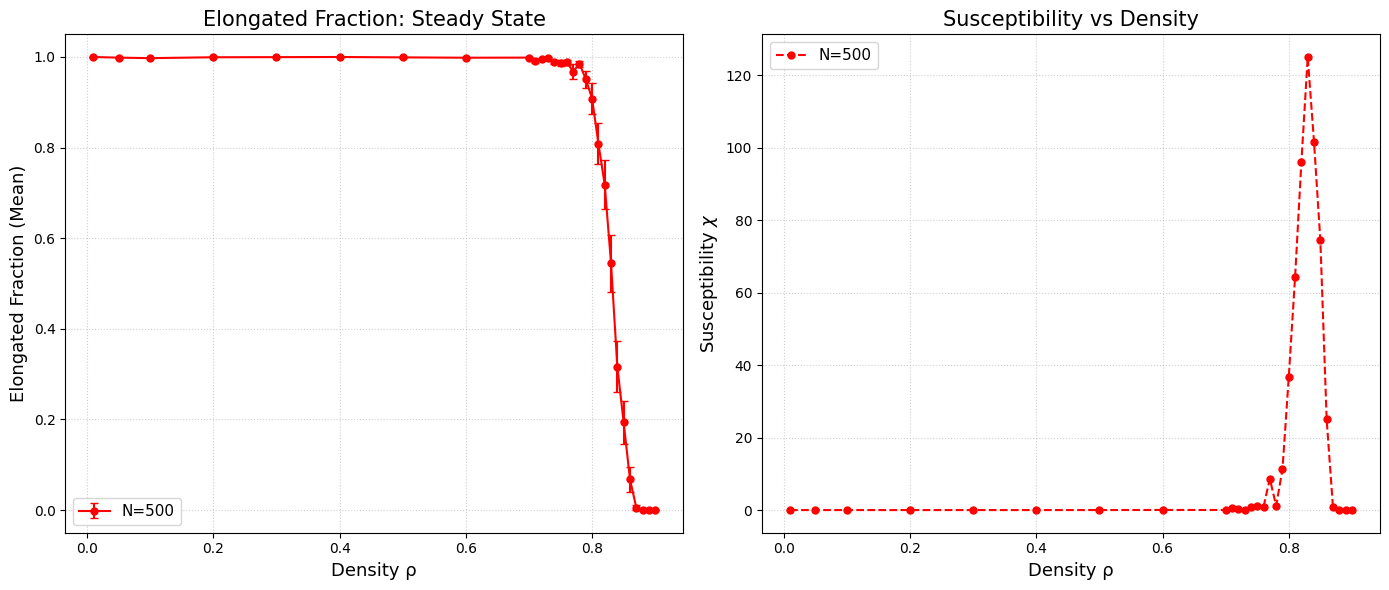

In [12]:
# Define the data for each N
comparison_data = {
    500: [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77, 0.78, 0.79, 0.8, 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87, 0.88, 0.89, 0.9],
    # 1000: [...], 
}

colors = ["red", "blue", "green", "orange", "purple"]

# Dictionary with metrics to plot
metrics_to_plot = {
    "polar": "Polar order (P)",
    "polar_2": r"Polar order ($\hat{P}$)",
    "fraction_elongated": "Elongated Fraction"
}

# Iterate for metrics
for metric_to_plot, metric_label in metrics_to_plot.items():
    
    # Initialize one figure with two subplots side-by-side
    fig, (ax_mean, ax_susc) = plt.subplots(1, 2, figsize=(14, 6))

    # Iterate over N
    for i, (N, density_list) in enumerate(comparison_data.items()):
        # Get the summary
        df_summary = get_op_steady_state_summary(N, density_list)
        
        if df_summary.empty:
            continue

        # Calculate the standard error for the mean
        sem = df_summary[f"{metric_to_plot}_std"] / np.sqrt(df_summary["n_realizations"])
        
        # Plot mean (Left Panel)
        ax_mean.errorbar(
            df_summary["density"], df_summary[metric_to_plot], 
            yerr=sem, fmt='o-', color=colors[i], label=f"N={N:,}", 
            capsize=3, markersize=5, lw=1.5
        )
        
        # Calculate and plot Susceptibility: Chi = N * Variance (Right Panel)
        # Variance = std^2
        susceptibility = N * (df_summary[f"{metric_to_plot}_std"]**2)
        
        ax_susc.plot(
            df_summary["density"], susceptibility, 
            'o--', color=colors[i], label=f"N={N:,}", 
            markersize=5, lw=1.5
        )

    # Settings Mean
    ax_mean.set_xlabel("Density ρ", fontsize=13)
    ax_mean.set_ylabel(f"{metric_label} (Mean)", fontsize=13)
    ax_mean.set_title(f"{metric_label}: Steady State", fontsize=15)
    ax_mean.legend(fontsize=11)
    ax_mean.grid(True, linestyle=':', alpha=0.6)

    # Settings Susceptibility
    ax_susc.set_xlabel("Density ρ", fontsize=13)
    ax_susc.set_ylabel(r"Susceptibility $\chi$", fontsize=13)
    ax_susc.set_title(f"Susceptibility vs Density", fontsize=15)
    ax_susc.legend(fontsize=11)
    ax_susc.grid(True, linestyle=':', alpha=0.6)

    # Save
    output_path = CONFIG["base_graph_path"] / "N_comparison" #/ "order_parameters"
    output_path.mkdir(parents=True, exist_ok=True)

    fig.tight_layout()
    # Now saving as a single combined image
    fig.savefig(output_path / f"{metric_to_plot}_mean_and_susc.png", dpi=600)

# Show every plot
plt.show()